In [71]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [72]:
# results_folder = "./Epochs-25-nochecks-blockerTrue-avstraight-creepFalse/"
epochs = 500
# traffic_flow = 6480
traffic_flows = [2160, 3240, 4320, 5400, 6480, 7560, 8640]
blockers = ["True", "False"]
lefts = ["True", "False"]
rights = ["True", "False"]
creeps = ["True", "False"]
# results_folder = f"./Epochs-{epochs}-trafficflow-{traffic_flow}-nochecks-blocker{blocker}-left{left}-right{right}-avstraight-creep{creep}/"
results_file = "Experiment-Diagnostics.pkl"
# epochs = int(results_folder.split('Epochs-')[1].split('-')[0])
# print(epochs)

# with open(results_folder+results_file, "rb") as f:
#     data = pickle.load(f)

In [73]:
# num_collisions = len(data["AV-Path"])
# print(f"Total number of collisions: {num_collisions}")
# print(f"Percentage of attempts with collisions: {(num_collisions/epochs)*100:.2f}%")
# visible_vehicle_collisions = np.array(data["Collision-Vehicle-Visible-at-Decision"])
# print(f"Percentage of collisions with vehicles starting outside FOV: {100*(visible_vehicle_collisions==False).sum()/num_collisions:.2f}%")
# blocker_objects = np.array(data["Blocking-Objects"])
# left_blocks = (blocker_objects=="Vehicle in adjacent left lane.").sum()
# right_blocks = (blocker_objects=="Obstruction on near right corner.").sum()
# print(f"Collisions with left blocker: {100*left_blocks/num_collisions:.2f}%")
# print(f"Collisions with right blocker: {100*right_blocks/num_collisions:.2f}%")


In [74]:
results = []
labels = []

for creep in creeps:
    for blocker in blockers:
        if blocker == "True":
            for left in lefts:
                for right in rights:
                    result = []
                    if left == "False" and right == "False":
                        continue
                    labels.append(f"creep-{creep}-left_blocker-{left}-right_blocker-{right}")
                    for traffic_flow in traffic_flows:
                        results_folder = f"./Epochs-{epochs}-trafficflow-{traffic_flow}-nochecks-blocker{blocker}-left{left}-right{right}-avstraight-creep{creep}/"
                        with open(results_folder+results_file, "rb") as f:
                            data = pickle.load(f)
                        num_collisions = len(data["AV-Path"])
                        occluded_vehicle_collisions = (np.array(data["Collision-Vehicle-Visible-at-Decision"])==False).sum()
                        result.append(num_collisions)
                    results.append(result)
        
        else:
            left = "False"
            right = "False"
            result = []
            labels.append(f"creep-{creep}-left_blocker-{left}-right_blocker-{right}")
            for traffic_flow in traffic_flows:
                results_folder = f"./Epochs-{epochs}-trafficflow-{traffic_flow}-nochecks-blocker{blocker}-left{left}-right{right}-avstraight-creep{creep}/"
                with open(results_folder+results_file, "rb") as f:
                    data = pickle.load(f)
                num_collisions = len(data["AV-Path"])
                occluded_vehicle_collisions = (np.array(data["Collision-Vehicle-Visible-at-Decision"])==False).sum()
                result.append(num_collisions)
            results.append(result)


    

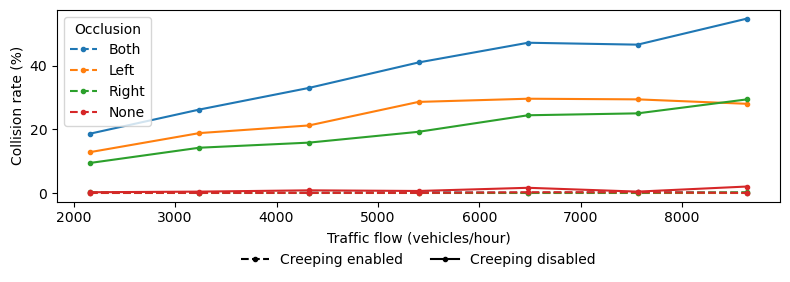

In [78]:
# print(labels)
# print(np.array(results))

labels = ["Both", "Left", "Right", "None",
          "Both", "Left", "Right", "None"]
plt.figure(figsize=(8,3))
colors = []  # store colors from first four plots

for i, label in enumerate(labels):
    y = (np.array(results[i]) / 500) * 100

    if i < 4:
        line, = plt.plot(
            traffic_flows, y,
            '.--', label=label
        )
        colors.append(line.get_color())  # save colour
    else:
        plt.plot(
            traffic_flows, y,
            '.-', color=colors[i - 4]
        )

# -------------------------
# Legend 1: Occlusion (colour)
# -------------------------
legend1 = plt.legend(
    labels[:4],
    loc="upper left",
    title="Occlusion"
)

# -------------------------
# Legend 2: Line style (creeping)
# -------------------------
style_handles = [
    Line2D([0], [0], linestyle='--', marker='.', color='black',
           label='Creeping enabled'),
    Line2D([0], [0], linestyle='-', marker='.', color='black',
           label='Creeping disabled')
]

legend2 = plt.legend(
    handles=style_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=2,
    frameon=False
)

# Add the first legend back explicitly
plt.gca().add_artist(legend1)

plt.xlabel("Traffic flow (vehicles/hour)")
plt.ylabel("Collision rate (%)")
plt.tight_layout()
# for i, label in enumerate(labels):
#     if i < 4:
#         plt.plot(traffic_flows, (np.array(results[i])/500)*100, '.--', label=label)
#     else:
#         plt.plot(traffic_flows, (np.array(results[i])/500)*100, '.-', label=label)

# plt.legend()
plt.savefig("collision_rate_data.pdf", format="pdf", bbox_inches="tight")